# Two Neuron Day 12 (27/01/2026)
***Phase 5- Day 3***

*First baseline learning model*

**Neuron A**

In [58]:
import numpy as np
import matplotlib.pyplot as plt
#Time parameters
dt=0.1
T=100
time=np.arange(0,T,dt)

# Neuron A parameters
V_rest_A=-65
V_A=np.zeros(len(time))
V_A[0]=V_rest_A

#Input Current (constant)
I_A = 6
tau_A=10

# Spikes A
V_th_A = -63
V_reset_A = -65
spikes_A= np.zeros(len(time))

#Refractory period 
refractory_period_A = 2
refractory_steps_A = int(refractory_period_A / dt)
refractory_timer_A= 0

#Noise
noise_std = 1
noise = np.random.normal(0,noise_std,len(time))

#Voltage update loop
for t in range(1,len(time)):
    if refractory_timer_A >0:
        V_A[t] = V_reset_A
        refractory_timer_A -= 1

    else:
        I_t = I_A+noise[t]
        dV_A= (-(V_A[t-1] - V_rest_A ) + I_t) * (dt/tau_A)
        V_A[t] = V_A[t-1] + dV_A

        if V_A[t] >= V_th_A :
            spikes_A[t] = 1
            V_A[t] = V_reset_A
            refractory_timer_A = refractory_steps_A

#Firing rate calculation
total_spikes_A = np.sum(spikes_A)
total_time_sec_A= T/1000

firing_rate_A = total_spikes_A / total_time_sec_A
firing_rate_A

np.float64(160.0)

**Spike Count Neuron A**

In [59]:
spike_count_A = np.sum(spikes_A)
spike_count_A

np.float64(16.0)

**Neuron A Graph**

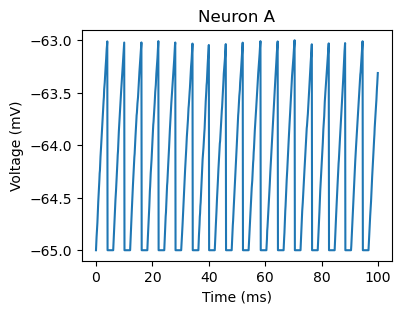

In [60]:
plt.figure(figsize=(4,3))
plt.plot(time,V_A)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Neuron A")
plt.show()

**Spike Train Neuron A**

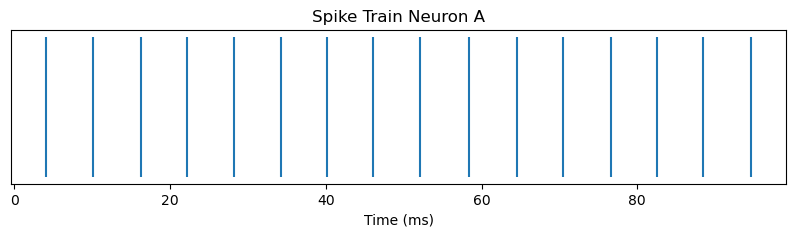

In [61]:
spike_times_A = time[spikes_A == 1]

plt.figure(figsize=(10,2))
plt.vlines(spike_times_A,ymin=0,ymax=1)
plt.xlabel("Time (ms)")
plt.yticks([])
plt.title("Spike Train Neuron A")
plt.show()

**Neuron B**

In [62]:
#Neuron A parameters 
V_rest_B = -65
V_B = np.zeros(len(time))
V_B[0] = V_rest_B

#Input Current (comes from Neuron A) 
# Synapthic connection from A-> B
w_AB = 15 + 10 * np.sin(2 * np.pi * np.arange(len(time)) / len(time))
I_B= np.zeros(len(time))
syn_current_B = np.zeros(len(time))

#Inhibitory synapse from A-> B
w_AiB = 4.0
syn_current_inh_B = np.zeros(len(time))

# Synaptic decay constants
alpha_exc = 0.90    # slow decay (excitation accumulates)
alpha_inh = 0.85    # faster decay (inhibition is brief)

#Spikes
V_th_B = -63
V_reset_B = -65
spikes_B = np.zeros(len(time))

#Refractory period
refractory_period_B = 2
refractory_steps_B = int(refractory_period_B / dt)
refractory_timer_B =0

# Voltage update loop for Neuron B
for t in range(1,len(time)):
    # Excitatory synapse (A -> B)
    syn_current_B[t] = (
        alpha_exc * syn_current_B[t-1]
        + w_AB[t] * spikes_A[t-1]
    )

    # Inhibitory synapse (A -> B)
    syn_current_inh_B[t] = (
        alpha_inh * syn_current_inh_B[t-1]
        + w_AiB * spikes_A[t-1]
    )

    # Net synaptic input
    I_B[t] = syn_current_B[t] - syn_current_inh_B[t]

    if refractory_timer_B>0:
        V_B[t] = V_reset_B
        refractory_timer_B-=1

    else:
        dV_B = (-(V_B[t-1] - V_rest_B) + I_B[t]) * (dt / tau_A)
        V_B[t] = V_B[t-1] + dV_B

        if V_B[t] >= V_th_B:
            spikes_B[t]=1
            V_B[t] = V_reset_B
            refractory_timer_B = refractory_steps_B

#Firing rate calculation
total_spikes_B = np.sum(spikes_B)
total_time_sec_B= T/1000

firing_rate_B = total_spikes_B / total_time_sec_B
firing_rate_B

np.float64(40.0)

**Spike Count Neuron B**

In [63]:
spike_count_B = np.sum(spikes_B)
spike_count_B

np.float64(4.0)

**Neuron B Graph**

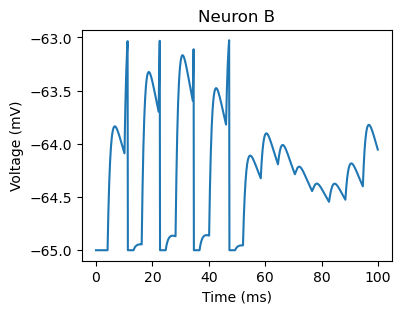

In [64]:
plt.figure(figsize=(4,3))
plt.plot(time,V_B)
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (mV)")
plt.title("Neuron B")
plt.show()

**Spike Train Neuron B**

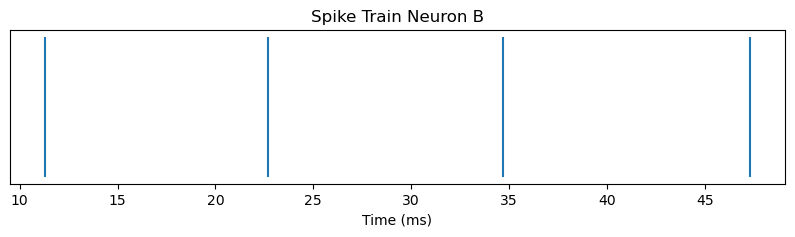

In [65]:
spike_times_B = time[spikes_B == 1]

plt.figure(figsize = (10,2))
plt.vlines(spike_times_B,ymin=0,ymax=1)
plt.xlabel("Time (ms)")
plt.yticks([])
plt.title("Spike Train Neuron B")
plt.show()

**Inter-Spike Interal (ISI)**

In [66]:
spike_times_A = time[spikes_A == 1]
spike_times_B = time[spikes_B == 1]

isi_A = np.diff(spike_times_A)
isi_B = np.diff(spike_times_B)

len(isi_A),len(isi_B)

(15, 3)

In [67]:
# mean ISI
mean_isi_A = np.mean(isi_A)
mean_isi_B = np.mean(isi_B)

mean_isi_A,mean_isi_B

(np.float64(6.033333333333334), np.float64(12.0))

In [68]:
# isi variance
std_isi_A = np.std(isi_A)
std_isi_B = np.std(isi_B)

std_isi_A,std_isi_B

(np.float64(0.12472191289246629), np.float64(0.4898979485566353))

In [69]:
# Coefficient of Variations (CV)
cv_A = np.std(isi_A)/ np.mean(isi_A)
cv_B = np.std(isi_B)/ np.mean(isi_B)
cv_A,cv_B

(np.float64(0.020672140258419822), np.float64(0.04082482904638628))

**Plot ISI for A**

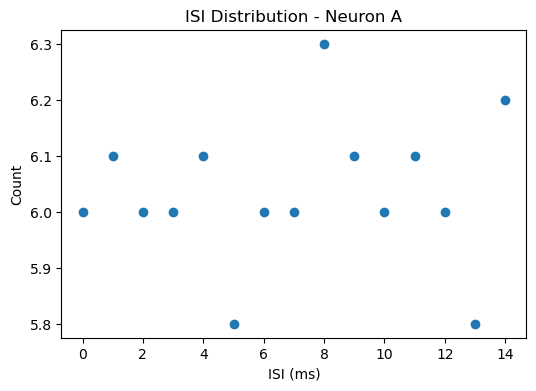

In [70]:
plt.figure(figsize=(6,4))
plt.plot(isi_A,'o')
plt.xlabel("ISI (ms)")
plt.ylabel("Count")
plt.title("ISI Distribution - Neuron A")
plt.show()

Plotting inter-spike intervals (ISI) as individual values shows that all ISIs collapse to a single constant value.
This indicates highly regular, tonic firing behavior of the neuron under constant input.
Such deterministic firing patterns are characteristic of LIF neurons without noise or time-varying inputs.
This regular baseline serves as a reference for later comparisons involving inhibition, noise, or modulation.

**Plot ISI for B**

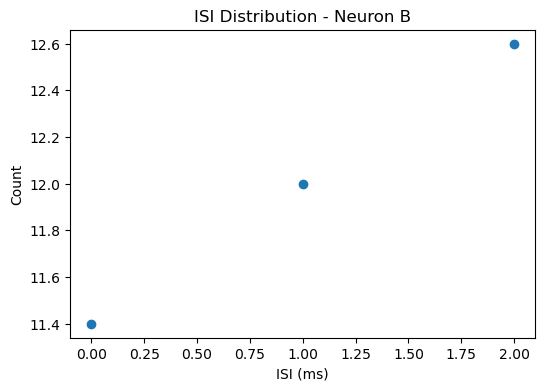

In [71]:
plt.figure(figsize=(6,4))
plt.plot(isi_B,'o')
plt.xlabel("ISI (ms)")
plt.ylabel("Count")
plt.title("ISI Distribution - Neuron B")
plt.show()

# Feature Vectors

In [72]:
# Feature Vector Neuron A
features_A = {
    "spike_count" : spike_count_A,
    "firing_rate" : firing_rate_A,
    "mean_isi" : np.mean(isi_A),
    "std_isi" : np.std(isi_A),
    "cv" : np.std(isi_A) / np.mean(isi_A)
}

features_A

{'spike_count': np.float64(16.0),
 'firing_rate': np.float64(160.0),
 'mean_isi': np.float64(6.033333333333334),
 'std_isi': np.float64(0.12472191289246629),
 'cv': np.float64(0.020672140258419822)}

In [73]:
# Feature Vector Neuron B
if len(isi_B) > 1:
    mean_isi_B = np.mean(isi_B)
    std_isi_B = np.std(isi_B)
    cv_B = std_isi_B / mean_isi_B
else:
    mean_isi_B = np.nan
    std_isi_B = np.nan
    cv_B = np.nan

features_B = {
    "spike_count" : spike_count_B,
    "firing_rate" : firing_rate_B,
    "mean_isi" : mean_isi_B,
    "std_isi" : std_isi_B,
    "cv" : cv_B
}

features_B

{'spike_count': np.float64(4.0),
 'firing_rate': np.float64(40.0),
 'mean_isi': np.float64(12.0),
 'std_isi': np.float64(0.4898979485566353),
 'cv': np.float64(0.04082482904638628)}

In [74]:
#Feature Table
import pandas as pd

feature_table = pd.DataFrame(
    [features_A,features_B],
    index=["Neuron_A", "Neuron_B"]
)
feature_table

,spike_count,firing_rate,mean_isi,std_isi,cv
Neuron_A,16.0,160.0,6.033333,0.124722,0.020672
Neuron_B,4.0,40.0,12.000000,0.489898,0.040825


## Simulation

In [75]:
input_currents = [2,4,6,8]
def run_simulation(I_value):
    V_rest = -65
    V_th = -63
    V_reset = -65
    tau = 10
    dt = 0.1
    T = 100
    time = np.arange(0, T, dt)

    V = np.zeros(len(time))
    V[0] = V_rest
    spikes = np.zeros(len(time))

    for t in range(1, len(time)):
        dV = (-(V[t-1] - V_rest) + I_value) * (dt / tau)
        V[t] = V[t-1] + dV

        if V[t] >= V_th:
            spikes[t] = 1
            V[t] = V_reset

    spike_times = time[spikes == 1]
    isi = np.diff(spike_times)

    spike_count = np.sum(spikes)
    firing_rate = spike_count / (T / 1000)

    if len(isi) > 1:
        mean_isi = np.mean(isi)
        std_isi = np.std(isi)
        cv = std_isi / mean_isi
    else:
        mean_isi = std_isi = cv = np.nan

    return {
        "I": I_value,
        "spike_count": spike_count,
        "firing_rate": firing_rate,
        "mean_isi": mean_isi,
        "std_isi": std_isi,
        "cv": cv
    }

results = []

for I_val in input_currents:
    features = run_simulation(I_val)
    results.append(features)

dataset = pd.DataFrame(results)
dataset["label"] = (dataset["I"] >= 6).astype(int)
dataset

,I,spike_count,firing_rate,mean_isi,std_isi,cv,label
0,2,0.0,0.0,NaN,NaN,NaN,0
1,4,14.0,140.0,6.9,4.062684e-15,5.887947e-16,0
2,6,24.0,240.0,4.1,4.850632e-15,1.183081e-15,1
3,8,34.0,340.0,2.9,4.351168e-15,1.500403e-15,1


In [76]:
dataset.describe()

,I,spike_count,firing_rate,mean_isi,std_isi,cv,label
count,4.000000,4.000000,4.000000,3.000000,3.000000e+00,3.000000e+00,4.00000
mean,5.000000,18.000000,180.000000,4.633333,4.421495e-15,1.090759e-15,0.50000
std,2.581989,14.514361,145.143607,2.052641,3.986543e-16,4.627632e-16,0.57735
min,2.000000,0.000000,0.000000,2.900000,4.062684e-15,5.887947e-16,0.00000
25%,3.500000,10.500000,105.000000,3.500000,4.206926e-15,8.859379e-16,0.00000
50%,5.000000,19.000000,190.000000,4.100000,4.351168e-15,1.183081e-15,0.50000
75%,6.500000,26.500000,265.000000,5.500000,4.600900e-15,1.341742e-15,1.00000
max,8.000000,34.000000,340.000000,6.900000,4.850632e-15,1.500403e-15,1.00000


[]

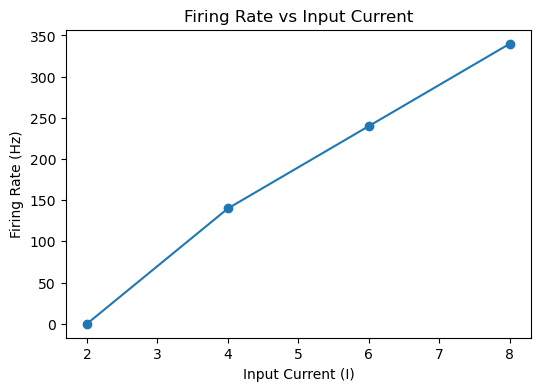

In [77]:
#Input current vs firing rate
plt.figure(figsize=(6,4))
plt.plot(dataset["I"],dataset["firing_rate"],marker='o')
plt.xlabel("Input Current (I)")
plt.ylabel("Firing Rate (Hz)")
plt.title("Firing Rate vs Input Current")
plt.plot()

[]

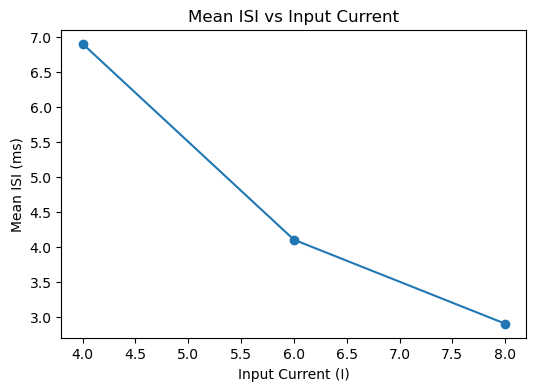

In [78]:
#Input Curent vs Mean ISI
plt.figure(figsize=(6,4))
plt.plot(dataset["I"],dataset["mean_isi"],marker='o')
plt.xlabel("Input Current (I)")
plt.ylabel("Mean ISI (ms)")
plt.title("Mean ISI vs Input Current")
plt.plot()

In [79]:
#Feature Correlation
dataset[["spike_count","firing_rate","mean_isi","std_isi","cv"]].corr()

,spike_count,firing_rate,mean_isi,std_isi,cv
spike_count,1.000000,1.000000,-0.974355,0.361823,0.984962
firing_rate,1.000000,1.000000,-0.974355,0.361823,0.984962
mean_isi,-0.974355,-0.974355,1.000000,-0.562316,-0.998579
std_isi,0.361823,0.361823,-0.562316,1.000000,0.517448
cv,0.984962,0.984962,-0.998579,0.517448,1.000000


## Feature Scaling

In [80]:
from sklearn.preprocessing import StandardScaler

features= dataset[["spike_count","firing_rate","mean_isi","std_isi","cv"]]

scaler = StandardScaler()
scaled_features= scaler.fit_transform(features)

scaled_df = pd.DataFrame(
    scaled_features,
    columns=features.columns
)

scaled_df

,spike_count,firing_rate,mean_isi,std_isi,cv
0,-1.432003,-1.432003,NaN,NaN,NaN
1,-0.318223,-0.318223,1.352447,-1.102339,-1.328496
2,0.477334,0.477334,-0.318223,1.318396,0.244337
3,1.272892,1.272892,-1.034224,-0.216058,1.084158


## Why Scaling matters ?

**Without scaling:**
- firing rate dominates
- ISI-bases features got ignored

**With scaling:**
- model can see all features
- interpretation becomes meaningful

## Handle NaNs

In [84]:
scaled_df.isna().sum()
X=scaled_df
y= dataset["label"]

valid_idx = ~scaled_df.isna().any(axis=1)
X_clean = scaled_df[valid_idx]
y_clean = y[valid_idx]

## Logistic Regression

In [85]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_clean,y_clean)

LogisticRegression()

## Predictions

In [86]:
predictions = model.predict(X_clean)
predictions

array([0, 1, 1])

In [87]:
y_clean.values

array([0, 1, 1])

## Accuracy

In [88]:
from sklearn.metrics import accuracy_score

accuracy_score(y_clean,predictions)

1.0

## Feature importance

In [89]:
importance = pd.Series(
    model.coef_[0],
    index=X_clean.columns
).sort_values(ascending=False)

importance

cv             0.453279
std_isi        0.430736
spike_count    0.264206
firing_rate    0.264206
mean_isi      -0.464852
dtype: float64

# Observation
Initial model training failed due to missing values in ISI-based features, arising from sparse spike activity under certain conditions.
After removing samples containing NaNs, a baseline logistic regression model was successfully trained.

This highlights the importance of handling incomplete feature representations before applying learning algorithms.
A baseline logistic regression model successfully classified neural activity under low and high input conditions.
Feature importance analysis reveals that temporal spike features, particularly mean ISI and variability measures (CV and ISI standard deviation), contribute strongly to classification.
This indicates that spike timing structure, beyond firing rate alone, encodes meaningful information about neural input conditions.

